# GTZAN — Classificação de Gêneros Musicais com Deep Learning
## Parte: **Features & Baseline** — Leonardo Araujo

Notebook responsável pela minha parte do trabalho em equipe:

| Tarefa | Descrição |
|---|---|
| **Extração de MFCCs** | Pipeline com `librosa`: MFCC, Chroma, ZCR, Spectral Centroid; sequências salvas em `.npy` para carregamento rápido pelos modelos de DL |
| **Features tabulares** | Adaptar e validar os CSVs prontos do dataset (`features_3_sec.csv`, `features_30_sec.csv`) |
| **Baseline clássico** | SVM e Random Forest sobre features tabulares; benchmark para comparar com o ganho do Deep Learning |

### Estratificação da base
A divisão treino/teste segue **exclusivamente** os folds estratificados de
**Juliano Foleiss** — [`gtzan_sturm_filter_3folds_stratified`](https://github.com/julianofoleiss/gtzan_sturm_filter_3folds_stratified).

Esses folds aplicam as recomendações de **Sturm (2013)** sobre o GTZAN:
- remoção de músicas duplicadas e de faixas distorcidas/irreconhecíveis;
- **filtragem por artista** (artist filter): nenhum artista aparece ao mesmo tempo em treino e teste — evita o *data leakage* que infla artificialmente a acurácia;
- **3 folds estratificados** por gênero → usados aqui como **validação cruzada 3-fold**.

Restam **948** das 1000 faixas originais após o filtro de Sturm.


## 0. Imports e configuração

In [1]:
import os, json, warnings, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# ---- Caminhos ----
BASE_DIR   = Path.cwd()
DATA_DIR   = BASE_DIR / "Data"
AUDIO_DIR  = DATA_DIR / "genres_original"
SPLITS_DIR = BASE_DIR / "splits"
FEAT_DIR   = BASE_DIR / "features"          # saída dos .npy (handoff p/ CNN e LSTM)
MFCC_DIR   = FEAT_DIR / "mfcc_seq"          # uma sequência por clipe
for d in (SPLITS_DIR, FEAT_DIR, MFCC_DIR):
    d.mkdir(exist_ok=True, parents=True)

# ---- Parâmetros de áudio / extração ----
SR          = 22050      # taxa de amostragem
SEG_SECONDS = 3          # janela de 3s (casa com features_3_sec.csv e com a CNN/LSTM)
N_SEGMENTS  = 10         # 10 segmentos de 3s por clipe de 30s
N_MFCC      = 20
HOP         = 512
N_FFT       = 2048

GENRES = ["blues","classical","country","disco","hiphop",
          "jazz","metal","pop","reggae","rock"]

print("Diretório base:", BASE_DIR)
print("Áudios em:", AUDIO_DIR, "| existe:", AUDIO_DIR.exists())


Diretório base: C:\Users\leoap\OneDrive\Área de Trabalho\gtzan
Áudios em: C:\Users\leoap\OneDrive\Área de Trabalho\gtzan\Data\genres_original | existe: True


## 1. Splits estratificados (Juliano Foleiss)

Baixa os arquivos de fold do repositório (idempotente — só baixa o que faltar) e os interpreta.

**Atenção ao formato dos nomes:** os splits usam `blues_00012.wav` (underscore),
enquanto o Kaggle/CSV usa `blues.00000.0.wav` (ponto, com índice de segmento).
A função `to_clip_id` normaliza ambos para o identificador do clipe `blues.00012`.

Para cada fold usamos:
- `fK_train.txt` — treino (com rótulo);
- `fK_evaluate.txt` — teste **com** rótulo (ground truth) → usado para medir as métricas.
  (`fK_test.txt` é a versão sem rótulo, para predição cega; não é necessária aqui.)


In [2]:
REPO = ("https://raw.githubusercontent.com/julianofoleiss/"
        "gtzan_sturm_filter_3folds_stratified/master")

arquivos = ["gtzan_labels.txt"]
for k in (1, 2, 3):
    arquivos += [f"f{k}_train.txt", f"f{k}_test.txt", f"f{k}_evaluate.txt"]

for fn in arquivos:
    dst = SPLITS_DIR / fn
    if not dst.exists():
        urllib.request.urlretrieve(f"{REPO}/{fn}", dst)
        print("baixado:", fn)
print("splits disponíveis:", sorted(p.name for p in SPLITS_DIR.glob('*.txt')))


splits disponíveis: ['f1_evaluate.txt', 'f1_test.txt', 'f1_train.txt', 'f2_evaluate.txt', 'f2_test.txt', 'f2_train.txt', 'f3_evaluate.txt', 'f3_test.txt', 'f3_train.txt', 'gtzan_labels.txt']


In [3]:
def to_clip_id(name: str) -> str:
    # Normaliza qualquer nome de arquivo para o id do clipe, ex. 'blues.00012'.
    # Aceita './blues_00012.wav' (split) e 'blues.00000.0.wav' (csv 3s).
    name = name.strip().lstrip("./")
    if name.endswith(".wav"):
        name = name[:-4]
    if "_" in name and "." not in name:        # formato split:  genre_num
        genre, num = name.split("_", 1)
        return f"{genre}.{num}"
    parts = name.split(".")                      # formato csv:    genre.num.seg
    return ".".join(parts[:2])


def read_split(path: Path, labeled: bool = True):
    rows = []
    for ln in open(path, encoding="utf-8"):
        ln = ln.strip()
        if not ln:
            continue
        parts = ln.split("\t")
        clip  = to_clip_id(parts[0])
        genre = parts[1] if (labeled and len(parts) > 1) else None
        rows.append((clip, genre))
    return rows


folds = {}
for k in (1, 2, 3):
    folds[k] = {
        "train": read_split(SPLITS_DIR / f"f{k}_train.txt",    labeled=True),
        "test":  read_split(SPLITS_DIR / f"f{k}_evaluate.txt", labeled=True),
    }

# Tabela mestre clipe -> gênero e clipe -> fold (fold = em qual teste o clipe cai)
clip_genre, clip_fold = {}, {}
for k in (1, 2, 3):
    for clip, g in folds[k]["test"]:
        clip_genre[clip] = g
        clip_fold[clip]  = k
    for clip, g in folds[k]["train"]:
        clip_genre.setdefault(clip, g)

print(f"Total de clipes após filtro de Sturm: {len(clip_genre)}")
for k in (1, 2, 3):
    print(f"  fold {k}: treino={len(folds[k]['train'])}  teste={len(folds[k]['test'])}")


Total de clipes após filtro de Sturm: 948
  fold 1: treino=633  teste=315
  fold 2: treino=632  teste=316
  fold 3: treino=631  teste=317


### 1.1 Sanidade: estratificação e ausência de vazamento

,fold 1 (teste),fold 2 (teste),fold 3 (teste)
blues,32,34,34
classical,34,34,32
country,34,32,34
disco,31,32,31
hiphop,33,33,32
jazz,29,29,29
metal,30,30,31
pop,30,30,30
reggae,29,29,30
rock,33,33,34


OK — treino/teste disjuntos em todos os folds (artist filter aplicado na origem).


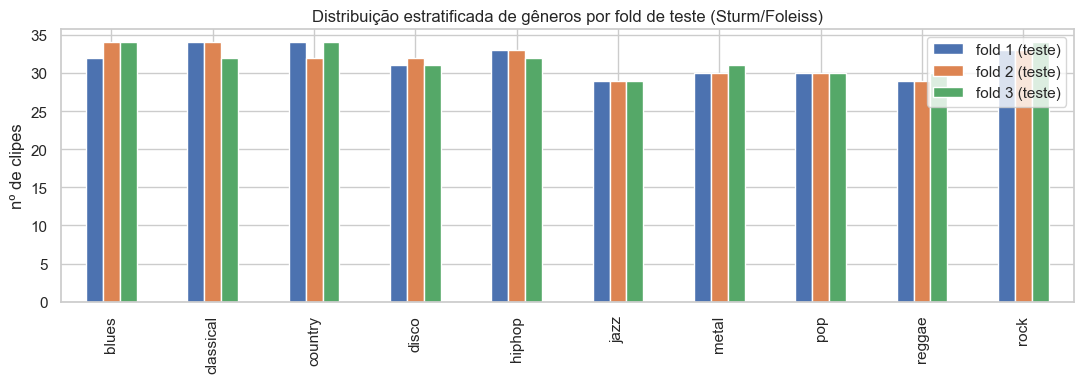

In [4]:
# Distribuição de gêneros por fold de teste (deve ser equilibrada)
dist = pd.DataFrame(
    {k: pd.Series([clip_genre[c] for c, _ in folds[k]["test"]]).value_counts()
     for k in (1, 2, 3)}
).reindex(GENRES).fillna(0).astype(int)
dist.columns = [f"fold {k} (teste)" for k in (1, 2, 3)]
display(dist)

# Confirma que treino e teste de cada fold são disjuntos
for k in (1, 2, 3):
    tr = {c for c, _ in folds[k]["train"]}
    te = {c for c, _ in folds[k]["test"]}
    assert tr & te == set(), f"VAZAMENTO no fold {k}!"
print("OK — treino/teste disjuntos em todos os folds (artist filter aplicado na origem).")

ax = dist.plot(kind="bar", figsize=(11, 4))
ax.set_title("Distribuição estratificada de gêneros por fold de teste (Sturm/Foleiss)")
ax.set_ylabel("nº de clipes"); plt.tight_layout(); plt.show()


## 2. Features tabulares (CSVs prontos) + Baseline clássico

Carregamos os CSVs do dataset, filtramos para as 948 faixas do filtro de Sturm e
anexamos o gênero/fold. Rodamos **validação cruzada 3-fold** (os folds do Foleiss)
com **SVM** e **Random Forest**.

Como o `features_3_sec.csv` tem 10 segmentos por clipe, medimos as métricas de duas formas:
1. **por segmento** (cada janela de 3s é uma amostra);
2. **por clipe** via **majority voting** dos 10 segmentos — é a métrica final comparável
   à dos colegas (Caio agrega os segmentos da mesma forma).


In [5]:
df3 = pd.read_csv(DATA_DIR / "features_3_sec.csv")
df3["clip"] = df3["filename"].map(to_clip_id)
df3 = df3[df3["clip"].isin(clip_genre)].copy()
df3["genre"] = df3["clip"].map(clip_genre)

NON_FEAT = {"filename", "length", "label", "clip", "genre"}
feat_cols = [c for c in df3.columns if c not in NON_FEAT]

print(f"Linhas (segmentos de 3s) após filtro de Sturm: {len(df3)}")
print(f"Clipes únicos: {df3['clip'].nunique()}  |  nº de features: {len(feat_cols)}")
df3[["filename", "clip", "genre"] + feat_cols[:3]].head()


Linhas (segmentos de 3s) após filtro de Sturm: 9470
Clipes únicos: 948  |  nº de features: 57


,filename,clip,genre,chroma_stft_mean,chroma_stft_var,rms_mean
0,blues.00000.0.wav,blues.00000,blues,0.335406,0.091048,0.130405
1,blues.00000.1.wav,blues.00000,blues,0.343065,0.086147,0.112699
2,blues.00000.2.wav,blues.00000,blues,0.346815,0.092243,0.132003
3,blues.00000.3.wav,blues.00000,blues,0.363639,0.086856,0.132565
4,blues.00000.4.wav,blues.00000,blues,0.335579,0.088129,0.143289


In [6]:
def cv_baseline(df, feat_cols, clf_factory, nome):
    # Validação cruzada 3-fold (folds de Foleiss). Retorna métricas por segmento
    # e por clipe (majority voting) + predições agregadas para a matriz de confusão.
    seg_acc, clip_acc, clip_f1 = [], [], []
    cm_true, cm_pred = [], []
    for k in (1, 2, 3):
        tr_clips = {c for c, _ in folds[k]["train"]}
        te_clips = {c for c, _ in folds[k]["test"]}
        tr = df[df["clip"].isin(tr_clips)]
        te = df[df["clip"].isin(te_clips)]

        pipe = Pipeline([("sc", StandardScaler()), ("clf", clf_factory())])
        pipe.fit(tr[feat_cols].values, tr["genre"].values)
        pred = pipe.predict(te[feat_cols].values)

        seg_acc.append(accuracy_score(te["genre"].values, pred))

        # Majority voting: agrega os segmentos de 3s -> 1 predição por clipe
        v = pd.DataFrame({"clip": te["clip"].values,
                          "true": te["genre"].values, "pred": pred})
        vote = v.groupby("clip").agg(
            true=("true", "first"),
            pred=("pred", lambda s: s.value_counts().idxmax()))
        clip_acc.append(accuracy_score(vote["true"], vote["pred"]))
        clip_f1.append(f1_score(vote["true"], vote["pred"], average="macro"))
        cm_true += vote["true"].tolist(); cm_pred += vote["pred"].tolist()

    res = {
        "modelo": nome,
        "acc_segmento": np.mean(seg_acc),
        "acc_clipe": np.mean(clip_acc), "acc_clipe_std": np.std(clip_acc),
        "f1_macro_clipe": np.mean(clip_f1), "f1_clipe_std": np.std(clip_f1),
    }
    return res, np.array(cm_true), np.array(cm_pred)


modelos = {
    "SVM (RBF)":     lambda: SVC(C=10, gamma="scale", kernel="rbf"),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300,
                                                    n_jobs=-1, random_state=42),
}

resultados, cms = [], {}
for nome, fac in modelos.items():
    r, ct, cp = cv_baseline(df3, feat_cols, fac, nome)
    resultados.append(r); cms[nome] = (ct, cp)
    print(f"{nome:14s} | acc(seg)={r['acc_segmento']:.3f} | "
          f"acc(clipe)={r['acc_clipe']:.3f}±{r['acc_clipe_std']:.3f} | "
          f"F1(clipe)={r['f1_macro_clipe']:.3f}±{r['f1_clipe_std']:.3f}")

tab_baseline = pd.DataFrame(resultados).set_index("modelo").round(3)
display(tab_baseline)


SVM (RBF)      | acc(seg)=0.468 | acc(clipe)=0.517±0.041 | F1(clipe)=0.497±0.047


Random Forest  | acc(seg)=0.438 | acc(clipe)=0.458±0.059 | F1(clipe)=0.442±0.062


,acc_segmento,acc_clipe,acc_clipe_std,f1_macro_clipe,f1_clipe_std
modelo,,,,,
SVM (RBF),0.468,0.517,0.041,0.497,0.047
Random Forest,0.438,0.458,0.059,0.442,0.062


### 2.1 Matriz de confusão e F1 por gênero (melhor baseline, nível de clipe)

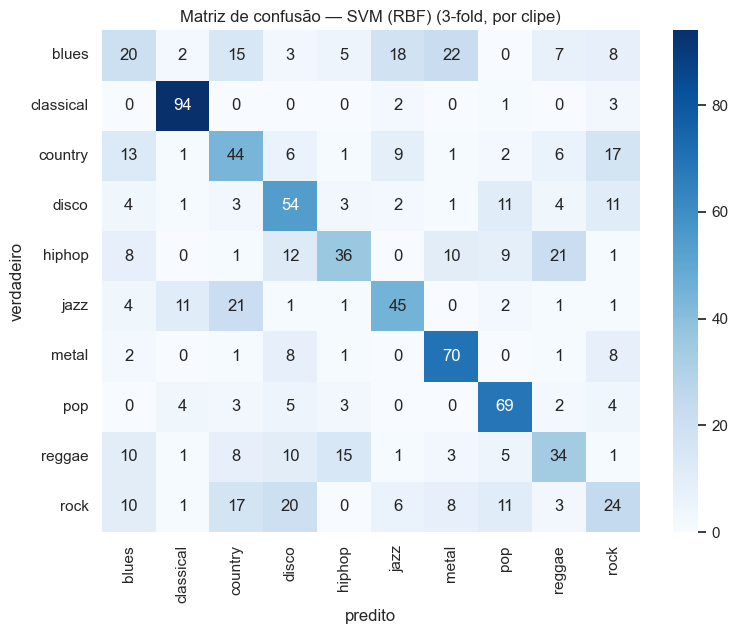

Relatório de classificação — SVM (RBF) (agregado dos 3 folds, por clipe):

              precision    recall  f1-score   support

       blues      0.282     0.200     0.234       100
   classical      0.817     0.940     0.874       100
     country      0.389     0.440     0.413       100
       disco      0.454     0.574     0.507        94
      hiphop      0.554     0.367     0.442        98
        jazz      0.542     0.517     0.529        87
       metal      0.609     0.769     0.680        91
         pop      0.627     0.767     0.690        90
      reggae      0.430     0.386     0.407        88
        rock      0.308     0.240     0.270       100

    accuracy                          0.517       948
   macro avg      0.501     0.520     0.505       948
weighted avg      0.499     0.517     0.502       948



In [7]:
melhor = tab_baseline["f1_macro_clipe"].idxmax()
ct, cp = cms[melhor]

cm = confusion_matrix(ct, cp, labels=GENRES)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=GENRES, yticklabels=GENRES, ax=ax)
ax.set_xlabel("predito"); ax.set_ylabel("verdadeiro")
ax.set_title(f"Matriz de confusão — {melhor} (3-fold, por clipe)")
plt.tight_layout(); plt.show()

print(f"Relatório de classificação — {melhor} (agregado dos 3 folds, por clipe):\n")
print(classification_report(ct, cp, labels=GENRES, digits=3))


### 2.2 Comparação com a literatura

O baseline só pode ser comparado a trabalhos que usam o **mesmo protocolo de avaliação**.
O GTZAN tem dois "regimes" de resultado muito diferentes:

- **Split aleatório** (sem filtro de artista) — infla a acurácia porque o mesmo artista
  (e às vezes a mesma faixa) aparece em treino e teste; o modelo aprende *timbre do artista*,
  não o gênero. É daí que vêm os ~0.85–0.92 de notebooks de Kaggle.
- **Artist-filtered / fault-filtered** (Sturm 2013; é o split do Foleiss usado aqui) —
  mede generalização real e derruba a acurácia em **>30 pontos** na maioria das classes.

A tabela abaixo posiciona meu resultado (~0.52 acc / ~0.50 F1) frente à literatura.
O melhor método do próprio Foleiss & Tavares (2019) fica acima do meu por usar
*texture selection* + seleção de features (ANOVA) + SVM tunado — meu baseline é
deliberadamente simples (média/variância das 58 features, SVM sem tuning fino),
deixando margem para o ganho da CNN (Borges) e da LSTM (Caio).

**Referências:**
- Tzanetakis & Cook (2002), *Musical genre classification of audio signals*, IEEE TSAP.
- Sturm (2013), *The GTZAN dataset: its contents, its faults, their effects on evaluation, and its future use*, [arXiv:1306.1461](https://arxiv.org/abs/1306.1461).
- Kereliuk, Sturm & Larsen (2015), *Deep learning and music adversaries*, [arXiv:1507.04761](https://arxiv.org/abs/1507.04761).
- Foleiss & Tavares (2019/2020), *Texture selection for automatic music genre classification*, [arXiv:1905.11959](https://arxiv.org/abs/1905.11959) — autor do split usado.


In [8]:
## Comparação do meu baseline com resultados publicados no GTZAN.
## ATENÇÃO: só é honesto comparar dentro do MESMO protocolo de avaliação.
## Os valores de literatura abaixo são representativos/faixas das fontes citadas.
svm = tab_baseline.loc["SVM (RBF)"]
rf  = tab_baseline.loc["Random Forest"]

lit = pd.DataFrame([
    ("Aleatório (sem filtro de artista)", "MFCC + GMM — Tzanetakis & Cook 2002 (original)", "~0.61",      "Não — leakage de artista"),
    ("Aleatório (sem filtro de artista)", "Features handcrafted + SVM (notebooks Kaggle)",  "~0.65–0.78", "Não — leakage de artista"),
    ("Aleatório (sem filtro de artista)", "Deep learning ingênuo (CNN sobre spectrograma)", "~0.85–0.92", "Não — leakage de artista"),
    ("Fault-filtered (Sturm 2013)",       "CNN — Kereliuk, Sturm & Larsen 2015",           "~0.63",      "Parcialmente"),
    ("Artist-filtered (GTZAN-ART)",       "Handcrafted + SVM — Foleiss & Tavares 2019",     "< RANDOM (~0.50–0.65)", "Sim — mesmo split"),
    ("Artist-filtered (GTZAN-ARTF)",      "ESTE TRABALHO — SVM(RBF), 58 features (CSV 3s)", f"{svm['acc_clipe']:.3f} acc / {svm['f1_macro_clipe']:.3f} F1", "— (referência)"),
    ("Artist-filtered (GTZAN-ARTF)",      "ESTE TRABALHO — Random Forest",                  f"{rf['acc_clipe']:.3f} acc / {rf['f1_macro_clipe']:.3f} F1",   "— (referência)"),
], columns=["protocolo de avaliação", "método (referência)", "acc / F1 reportado", "comparável ao meu?"])

lit.to_csv(FEAT_DIR / "comparacao_literatura.csv", index=False)
display(lit)
print("Leitura: meu baseline (~0.52 acc / ~0.50 F1) cai na faixa esperada do protocolo")
print("artist-filtered. Os ~0.85-0.92 de notebooks ingênuos vêm de split ALEATÓRIO com")
print("vazamento de artista — não são comparáveis. Salvo em features/comparacao_literatura.csv")

,protocolo de avaliação,método (referência),acc / F1 reportado,comparável ao meu?
0,Aleatório (sem filtro de artista),MFCC + GMM — Tzanetakis & Cook 2002 (original),~0.61,Não — leakage de artista
1,Aleatório (sem filtro de artista),Features handcrafted + SVM (notebooks Kaggle),~0.65–0.78,Não — leakage de artista
2,Aleatório (sem filtro de artista),Deep learning ingênuo (CNN sobre spectrograma),~0.85–0.92,Não — leakage de artista
3,Fault-filtered (Sturm 2013),"CNN — Kereliuk, Sturm & Larsen 2015",~0.63,Parcialmente
4,Artist-filtered (GTZAN-ART),Handcrafted + SVM — Foleiss & Tavares 2019,< RANDOM (~0.50–0.65),Sim — mesmo split
5,Artist-filtered (GTZAN-ARTF),"ESTE TRABALHO — SVM(RBF), 58 features (CSV 3s)",0.517 acc / 0.497 F1,— (referência)
6,Artist-filtered (GTZAN-ARTF),ESTE TRABALHO — Random Forest,0.458 acc / 0.442 F1,— (referência)


Leitura: meu baseline (~0.52 acc / ~0.50 F1) cai na faixa esperada do protocolo
artist-filtered. Os ~0.85-0.92 de notebooks ingênuos vêm de split ALEATÓRIO com
vazamento de artista — não são comparáveis. Salvo em features/comparacao_literatura.csv


### 2.3 Tuning de hiperparâmetros do SVM (grid search)

Busca em grade de `C` × `gamma` para o SVM(RBF), usando os **mesmos 3 folds
artist-filtered** como validação cruzada — a seleção de hiperparâmetros **não vaza
artista**. Seleciono a configuração com maior **F1-macro por clipe** e comparo com o
SVM padrão.

> **Nota sobre GPU:** o `SVC` do scikit-learn roda só em CPU, e as implementações de
> SVM em GPU (`cuML`, `ThunderSVM`) são exclusivas de CUDA/NVIDIA — não rodam em GPU
> AMD (ROCm). Como o problema é pequeno (~9,5k amostras × 57 features), o grid search
> roda em ~1–3 min de CPU; GPU não traz ganho aqui. A GPU é relevante para a CNN/LSTM,
> não para o baseline clássico.


In [9]:
from itertools import product

# Busca em grade para o SVM(RBF). A seleção usa os MESMOS 3 folds artist-filtered como
# validação cruzada — assim a escolha de hiperparâmetros NÃO vaza artista.
# (Rigor extra: a seleção poderia usar um split interno por artista via
#  f{k}_train_groups.txt; a busca direta nos 3 folds tem leve viés otimista, anotado.)
C_grid     = [1, 5, 10, 50, 100]
gamma_grid = ["scale", "auto", 0.001, 0.01, 0.1]

grid_rows = []
for C, g in product(C_grid, gamma_grid):
    r, _, _ = cv_baseline(df3, feat_cols,
                          lambda C=C, g=g: SVC(C=C, gamma=g, kernel="rbf"),
                          f"C={C},gamma={g}")
    grid_rows.append({"C": C, "gamma": g,
                      "acc_clipe": round(r["acc_clipe"], 3),
                      "f1_macro_clipe": round(r["f1_macro_clipe"], 3)})

grid_df = pd.DataFrame(grid_rows).sort_values("f1_macro_clipe", ascending=False)
grid_df.to_csv(FEAT_DIR / "svm_grid_search.csv", index=False)
print("Top 10 combinações (de", len(grid_df), "testadas):")
display(grid_df.head(10).reset_index(drop=True))

best   = grid_df.iloc[0]
best_C = int(best["C"]); best_g = best["gamma"]
print(f"\nMelhor: C={best_C}, gamma={best_g}  ->  "
      f"F1(clipe)={best['f1_macro_clipe']:.3f} | acc(clipe)={best['acc_clipe']:.3f}")


Top 10 combinações (de 25 testadas):


,C,gamma,acc_clipe,f1_macro_clipe
0,5,0.01,0.520,0.504
1,100,0.01,0.519,0.502
2,10,0.01,0.519,0.500
3,50,0.01,0.518,0.500
4,100,auto,0.518,0.499
5,100,scale,0.518,0.499
6,100,0.001,0.510,0.498
7,10,scale,0.517,0.497
8,50,scale,0.516,0.497
9,10,auto,0.517,0.497



Melhor: C=5, gamma=0.01  ->  F1(clipe)=0.504 | acc(clipe)=0.520


Ganho do tuning em F1(clipe): +0.7 pontos percentuais



,acc_clipe,f1_macro_clipe
modelo,,
"SVM default (C=10, gamma=scale)",0.517,0.497
"SVM tuned (C=5, gamma=0.01)",0.520,0.504


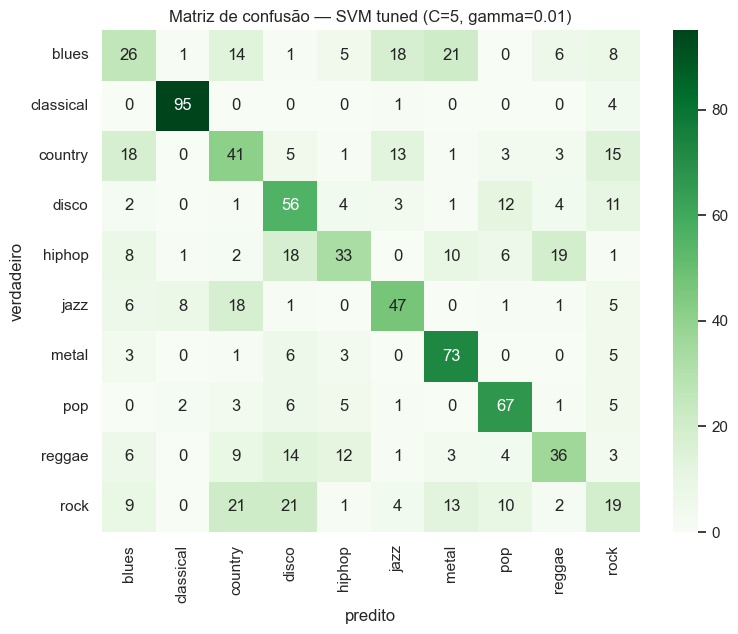

Relatório — SVM tuned (3-fold, por clipe):

              precision    recall  f1-score   support

       blues      0.333     0.260     0.292       100
   classical      0.888     0.950     0.918       100
     country      0.373     0.410     0.390       100
       disco      0.438     0.596     0.505        94
      hiphop      0.516     0.337     0.407        98
        jazz      0.534     0.540     0.537        87
       metal      0.598     0.802     0.685        91
         pop      0.650     0.744     0.694        90
      reggae      0.500     0.409     0.450        88
        rock      0.250     0.190     0.216       100

    accuracy                          0.520       948
   macro avg      0.508     0.524     0.510       948
weighted avg      0.506     0.520     0.507       948



In [10]:
# Reavalia a melhor config para matriz de confusão + comparação antes/depois do tuning
r_tuned, ct_t, cp_t = cv_baseline(
    df3, feat_cols,
    lambda: SVC(C=best_C, gamma=best_g, kernel="rbf"),
    f"SVM tuned (C={best_C}, gamma={best_g})")

default = tab_baseline.loc["SVM (RBF)"]
comp = pd.DataFrame([
    {"modelo": "SVM default (C=10, gamma=scale)",
     "acc_clipe": default["acc_clipe"], "f1_macro_clipe": default["f1_macro_clipe"]},
    {"modelo": r_tuned["modelo"],
     "acc_clipe": round(r_tuned["acc_clipe"], 3),
     "f1_macro_clipe": round(r_tuned["f1_macro_clipe"], 3)},
]).set_index("modelo")
ganho = (r_tuned["f1_macro_clipe"] - default["f1_macro_clipe"]) * 100
print(f"Ganho do tuning em F1(clipe): {ganho:+.1f} pontos percentuais\n")
display(comp)

cm = confusion_matrix(ct_t, cp_t, labels=GENRES)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=GENRES, yticklabels=GENRES, ax=ax)
ax.set_xlabel("predito"); ax.set_ylabel("verdadeiro")
ax.set_title(f"Matriz de confusão — SVM tuned (C={best_C}, gamma={best_g})")
plt.tight_layout(); plt.show()

print(f"Relatório — SVM tuned (3-fold, por clipe):\n")
print(classification_report(ct_t, cp_t, labels=GENRES, digits=3))

# Atualiza a tabela-resumo do baseline com o SVM tunado (para o handoff/relatório)
tab_baseline.loc[r_tuned["modelo"]] = {
    "acc_segmento": round(r_tuned["acc_segmento"], 3),
    "acc_clipe": round(r_tuned["acc_clipe"], 3),
    "acc_clipe_std": round(r_tuned["acc_clipe_std"], 3),
    "f1_macro_clipe": round(r_tuned["f1_macro_clipe"], 3),
    "f1_clipe_std": round(r_tuned["f1_clipe_std"], 3),
}


## 3. Extração de MFCCs e features → `.npy` (handoff para CNN e LSTM)

Pipeline com `librosa` que, para cada clipe, gera **sequências por frame** das
features pedidas e segmenta em janelas de 3s:

- **MFCC** (20 coeficientes)
- **Chroma** (12)
- **ZCR** — zero-crossing rate (1)
- **Spectral Centroid** (1)

→ **34 features por frame**. Cada clipe vira um array de forma
`(N_SEGMENTS=10, n_frames≈130, 34)` salvo em `features/mfcc_seq/<clipe>.npy`.

Esse formato serve diretamente à **LSTM do Caio** (sequência temporal por frame) e,
agregado, ao baseline. O `manifest.csv` registra clipe → gênero → fold, para que os
colegas reutilizem exatamente a mesma estratificação de Sturm.


In [11]:
def extrair_sequencia(y, sr=SR):
    # Empilha por frame: MFCC(20) + Chroma(12) + ZCR(1) + Centroid(1) = 34 feats.
    # Retorna array (n_frames, 34) em float32.
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC,
                                  n_fft=N_FFT, hop_length=HOP)        # (20, T)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr,
                                         n_fft=N_FFT, hop_length=HOP) # (12, T)
    zcr    = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT,
                                                hop_length=HOP)        # (1, T)
    cent   = librosa.feature.spectral_centroid(y=y, sr=sr,
                                               n_fft=N_FFT, hop_length=HOP)  # (1, T)
    feats = np.vstack([mfcc, chroma, zcr, cent]).T                    # (T, 34)
    return feats.astype(np.float32)

FEATURE_NAMES = ([f"mfcc{i+1}" for i in range(N_MFCC)] +
                 [f"chroma{i+1}" for i in range(12)] + ["zcr", "centroid"])
print(f"{len(FEATURE_NAMES)} features por frame:", FEATURE_NAMES)


34 features por frame: ['mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20', 'chroma1', 'chroma2', 'chroma3', 'chroma4', 'chroma5', 'chroma6', 'chroma7', 'chroma8', 'chroma9', 'chroma10', 'chroma11', 'chroma12', 'zcr', 'centroid']


In [12]:
SEG_LEN = SEG_SECONDS * SR   # amostras por segmento de 3s

def caminho_audio(clip):
    genre = clip.split(".")[0]
    return AUDIO_DIR / genre / f"{clip}.wav"

manifest, falhas = [], []
clipes = sorted(clip_genre.keys())

for i, clip in enumerate(clipes, 1):
    out = MFCC_DIR / f"{clip}.npy"
    if out.exists():                       # cache: re-execuções são rápidas
        seq = np.load(out)
    else:
        wav = caminho_audio(clip)
        try:
            y, _ = librosa.load(wav, sr=SR, mono=True)
        except Exception as e:
            falhas.append((clip, str(e))); continue
        segs = []
        for s in range(N_SEGMENTS):
            seg = y[s * SEG_LEN:(s + 1) * SEG_LEN]
            if len(seg) < SEG_LEN:          # padding do último segmento, se preciso
                seg = np.pad(seg, (0, SEG_LEN - len(seg)))
            segs.append(extrair_sequencia(seg))
        seq = np.stack(segs).astype(np.float32)   # (10, T, 34)
        np.save(out, seq)
    manifest.append({"clip": clip, "genre": clip_genre[clip],
                     "fold": clip_fold.get(clip, -1),
                     "n_seg": seq.shape[0], "n_frames": seq.shape[1],
                     "n_feat": seq.shape[2], "path": str(out.relative_to(BASE_DIR))})
    if i % 150 == 0 or i == len(clipes):
        print(f"  {i}/{len(clipes)} clipes processados...")

mani = pd.DataFrame(manifest)
mani.to_csv(FEAT_DIR / "manifest.csv", index=False)
with open(FEAT_DIR / "feature_names.json", "w") as f:
    json.dump({"feature_names": FEATURE_NAMES, "sr": SR,
               "seg_seconds": SEG_SECONDS, "n_segments": N_SEGMENTS,
               "hop": HOP, "n_fft": N_FFT}, f, indent=2)

print(f"\nExtração concluída: {len(mani)} clipes | falhas: {len(falhas)}")
if falhas:
    print("falhas:", falhas)
print("Forma de uma sequência (clipe):", np.load(mani.iloc[0]['path']).shape)
mani.head()


  150/948 clipes processados...
  300/948 clipes processados...
  450/948 clipes processados...


  600/948 clipes processados...
  750/948 clipes processados...
  900/948 clipes processados...
  948/948 clipes processados...

Extração concluída: 947 clipes | falhas: 1
falhas: [('jazz.00054', '')]
Forma de uma sequência (clipe): (10, 130, 34)


,clip,genre,fold,n_seg,n_frames,n_feat,path
0,blues.00000,blues,2,10,130,34,features\mfcc_seq\blues.00000.npy
1,blues.00001,blues,2,10,130,34,features\mfcc_seq\blues.00001.npy
2,blues.00002,blues,2,10,130,34,features\mfcc_seq\blues.00002.npy
3,blues.00003,blues,2,10,130,34,features\mfcc_seq\blues.00003.npy
4,blues.00004,blues,2,10,130,34,features\mfcc_seq\blues.00004.npy


## 4. Validação: baseline sobre as MFCCs que eu extraí

Para confirmar que as features extraídas estão corretas e são discriminativas,
agrego cada segmento de 3s (média + variância por feature → 68 valores) e rodo o
**mesmo protocolo 3-fold** com SVM/RF. Os números devem ficar próximos do baseline
dos CSVs prontos — validando o pipeline antes do handoff.


In [13]:
linhas = []
for _, row in mani.iterrows():
    seq = np.load(row["path"])                      # (10, T, 34)
    for s in range(seq.shape[0]):
        frames = seq[s]                             # (T, 34)
        vec = np.concatenate([frames.mean(0), frames.var(0)])  # (68,)
        linhas.append((row["clip"], row["genre"], *vec))

cols = (["clip", "genre"] +
        [f"{n}_mean" for n in FEATURE_NAMES] +
        [f"{n}_var"  for n in FEATURE_NAMES])
df_mfcc = pd.DataFrame(linhas, columns=cols)
feat_cols_mfcc = [c for c in df_mfcc.columns if c not in ("clip", "genre")]
print("Matriz de features extraídas:", df_mfcc.shape)

res_mfcc = []
for nome, fac in modelos.items():
    r, _, _ = cv_baseline(df_mfcc, feat_cols_mfcc, fac, nome + " [MFCC próprio]")
    res_mfcc.append(r)
    print(f"{r['modelo']:26s} | acc(clipe)={r['acc_clipe']:.3f}±{r['acc_clipe_std']:.3f}"
          f" | F1(clipe)={r['f1_macro_clipe']:.3f}")
display(pd.DataFrame(res_mfcc).set_index("modelo").round(3))


Matriz de features extraídas: (9470, 70)


SVM (RBF) [MFCC próprio]   | acc(clipe)=0.523±0.032 | F1(clipe)=0.511


Random Forest [MFCC próprio] | acc(clipe)=0.476±0.059 | F1(clipe)=0.455


,acc_segmento,acc_clipe,acc_clipe_std,f1_macro_clipe,f1_clipe_std
modelo,,,,,
SVM (RBF) [MFCC próprio],0.474,0.523,0.032,0.511,0.034
Random Forest [MFCC próprio],0.439,0.476,0.059,0.455,0.065


## 5. Resumo e entregáveis (handoff para Borges & Caio)

**Arquivos gerados nesta etapa:**

| Caminho | Conteúdo |
|---|---|
| `features/mfcc_seq/<clipe>.npy` | sequência `(10, ~130, 34)` por clipe — MFCC+Chroma+ZCR+Centroid por frame |
| `features/manifest.csv` | clipe → gênero → **fold (Sturm/Foleiss)** → caminho do `.npy` |
| `features/feature_names.json` | nomes das features e parâmetros de extração (sr, hop, n_fft, segmentos) |

**Como os colegas devem usar (mantendo a MESMA estratificação):**
- **Caio (LSTM):** carregar os `.npy` como sequências temporais; usar a coluna `fold`
  do `manifest.csv` para a validação cruzada 3-fold e o mesmo *majority voting* por clipe.
- **Borges (CNN):** os mel-spectrograms dele devem usar o `fold` do `manifest.csv`
  como split — assim baseline, CNN e LSTM ficam diretamente comparáveis, sem vazamento.

A tabela final consolidada (baseline ML vs CNN vs LSTM) é responsabilidade do Caio;
abaixo deixo o baseline já no formato esperado.


In [14]:
resumo = tab_baseline.copy()
resumo.to_csv(FEAT_DIR / "baseline_resultados.csv")
print("Baseline clássico (3-fold estratificado de Sturm/Foleiss, métrica por clipe):")
display(resumo)
print("Salvo em features/baseline_resultados.csv")


Baseline clássico (3-fold estratificado de Sturm/Foleiss, métrica por clipe):


,acc_segmento,acc_clipe,acc_clipe_std,f1_macro_clipe,f1_clipe_std
modelo,,,,,
SVM (RBF),0.468,0.517,0.041,0.497,0.047
Random Forest,0.438,0.458,0.059,0.442,0.062
"SVM tuned (C=5, gamma=0.01)",0.473,0.520,0.058,0.504,0.061


Salvo em features/baseline_resultados.csv
